# RL Training Analysis
Visualisation of training and episode logs from training loop

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

LOG_DIR = 'runs/3rd_Run_1000_episodes/logs'

with open(f'{LOG_DIR}/episode_log.json') as f:
    episode_log = json.load(f)

with open(f'{LOG_DIR}/training_log.json') as f:
    training = json.load(f)

cfg        = training['config']
results    = training['results']
ep_rewards = training['episode_rewards']
val        = training['validation']

# Episode dataframe 
ep_df = pd.DataFrame([{
    'episode':       e['episode'],
    'reward':        e['reward'],
    'steps':         e['steps'],
    'terminated':    e['terminated'],
    **e['final']
} for e in episode_log])

# Step-level dataframe (flattened)
step_rows = []
for e in episode_log:
    for s in e['steps_detail']:
        step_rows.append({'episode': e['episode'], **s})
step_df = pd.DataFrame(step_rows)

# Validation checkpoints (every validation_interval episodes)
val_interval = cfg.get('validation_interval', 50)
n_val        = len(val['rewards'])
val_episodes = [(i + 1) * val_interval for i in range(n_val)]

print(f"Loaded {len(ep_df)} episodes, {len(step_df)} steps")
print(f"Best training reward : {results['best_training_reward']:.4f}")
print(f"Best validation reward: {results['best_validation_reward']:.4f}")
print(f"Best Vn,in           : {results['best_vnin_nV']:.4f} nV/√Hz")
print(f"Success count        : {results['success_count']}")

Loaded 1000 episodes, 100000 steps
Best training reward : 30.6795
Best validation reward: 22.6670
Best Vn,in           : 4.0297 nV/√Hz
Success count        : 0


## 1 · Reward Curves

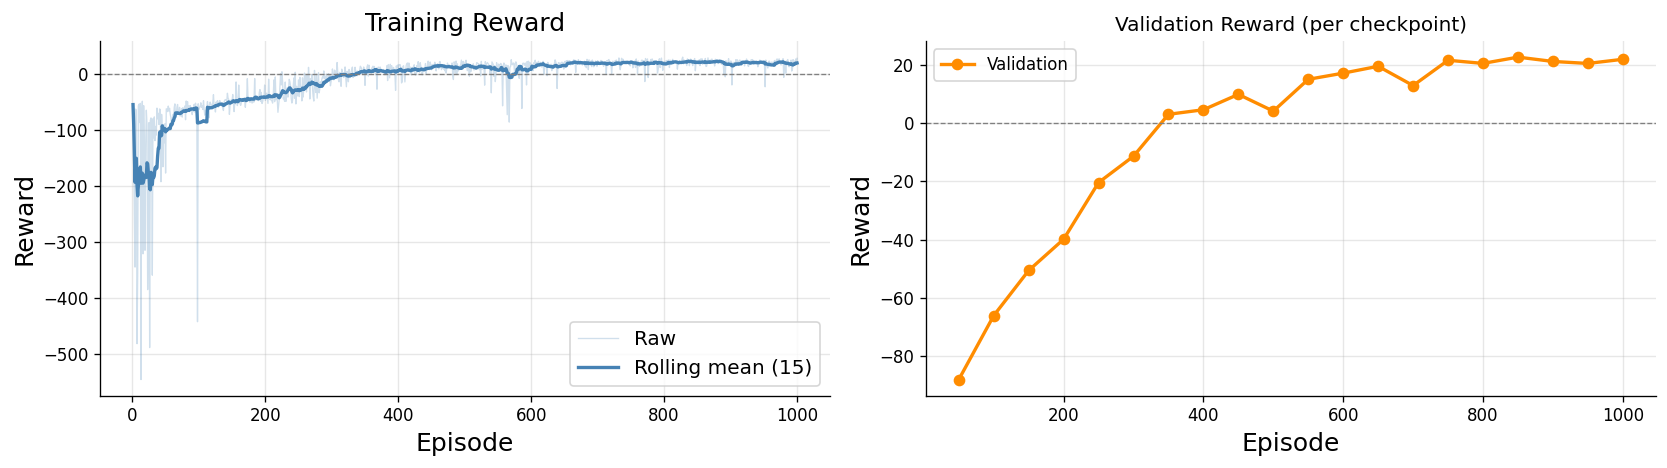

In [13]:
window = 15
smoothed = pd.Series(ep_rewards).rolling(window, min_periods=1).mean()
episodes = np.arange(1, len(ep_rewards) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw + smoothed training reward 
ax = axes[0]
ax.plot(episodes, ep_rewards, alpha=0.25, color='steelblue', linewidth=0.8, label='Raw')
ax.plot(episodes, smoothed,  color='steelblue', linewidth=2,   label=f'Rolling mean ({window})')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episode', fontsize=15)
ax.set_ylabel('Reward', fontsize=15)
ax.set_title('Training Reward', fontsize=15)
ax.legend(fontsize=12)

# Validation reward 
ax = axes[1]
ax.plot(val_episodes, val['rewards'], marker='o', color='darkorange', linewidth=2, label='Validation')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Episode', fontsize=15)
ax.set_ylabel('Reward', fontsize=15)
ax.set_title('Validation Reward (per checkpoint)')
ax.legend()
plt.savefig('TrainingReward.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 2 · Validation Metrics: Vn,in & Fc

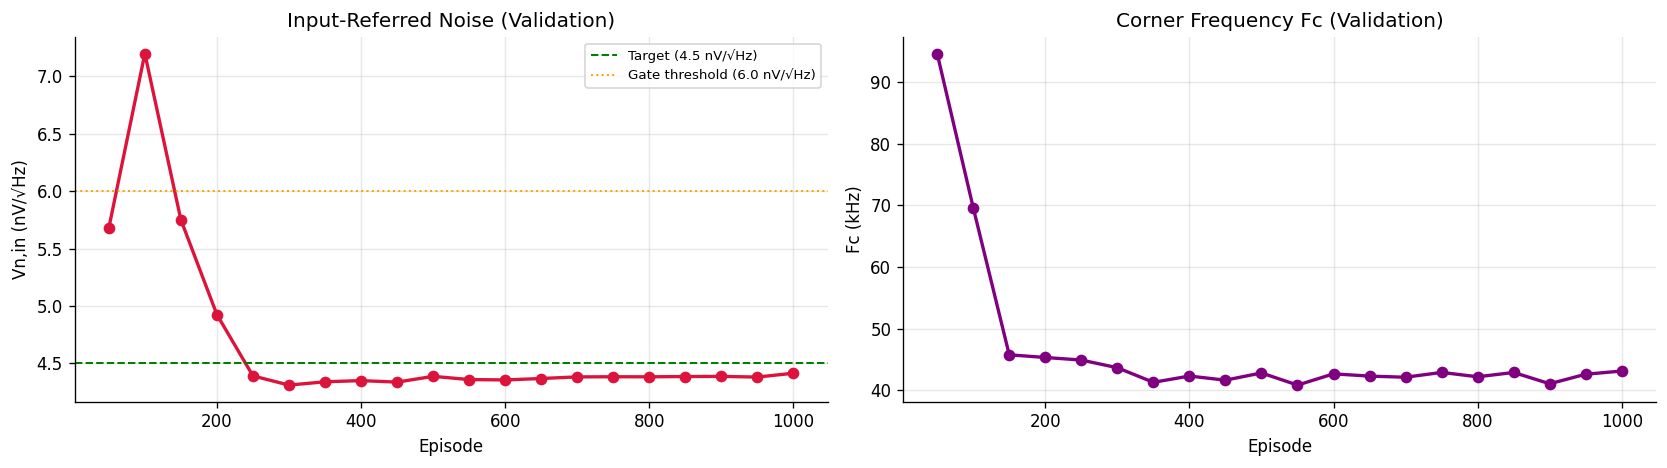

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Input-referred noise 
ax = axes[0]
ax.plot(val_episodes, val['vnins'], marker='o', color='crimson', linewidth=2)
ax.axhline(cfg['vnin_target'],            color='green',  linestyle='--', linewidth=1.2, label=f"Target ({cfg['vnin_target']} nV/√Hz)")
ax.axhline(cfg['vnin_gate_threshold'],    color='orange', linestyle=':',  linewidth=1.2, label=f"Gate threshold ({cfg['vnin_gate_threshold']} nV/√Hz)")
ax.set_xlabel('Episode')
ax.set_ylabel('Vn,in (nV/√Hz)')
ax.set_title('Input-Referred Noise (Validation)')
ax.legend(fontsize=8)

# Corner frequency 
ax = axes[1]
ax.plot(val_episodes, np.array(val['fcs']) / 1e3, marker='o', color='purple', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Fc (kHz)')
ax.set_title('Corner Frequency Fc (Validation)')

plt.tight_layout()
plt.show()

## 3 · Episode-Level Design Parameters

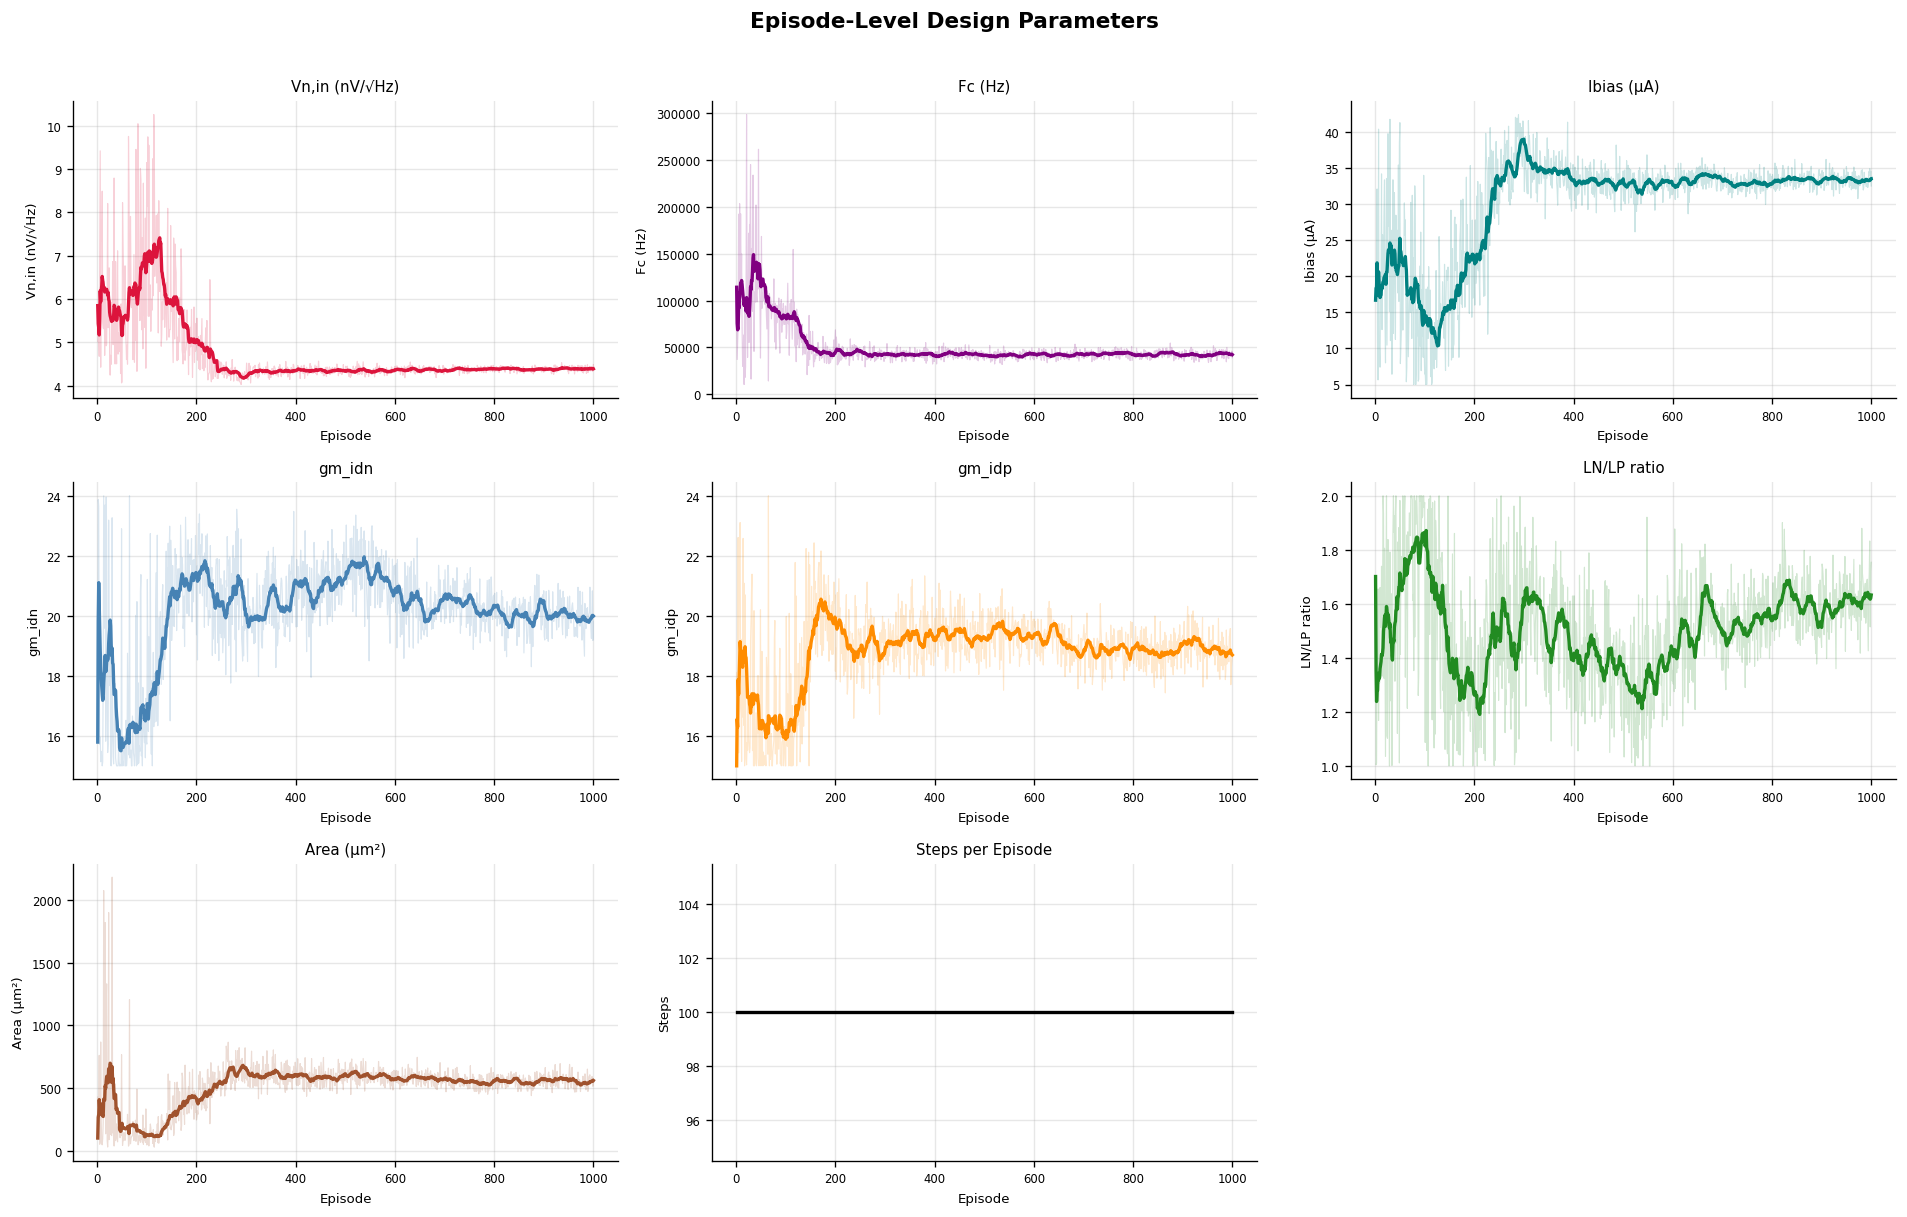

In [5]:
params = ['vn_in', 'fc', 'ibias_uA', 'gm_idn', 'gm_idp', 'ln_lp_ratio', 'area_um2']
titles = ['Vn,in (nV/√Hz)', 'Fc (Hz)', 'Ibias (µA)', 'gm_idn', 'gm_idp', 'LN/LP ratio', 'Area (µm²)']
colors = ['crimson','purple','teal','steelblue','darkorange','forestgreen','sienna']

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (p, title, c) in enumerate(zip(params, titles, colors)):
    ax = axes[i]
    vals = ep_df[p]
    rolled = vals.rolling(window, min_periods=1).mean()
    ax.plot(ep_df['episode'], vals,   alpha=0.2, color=c, linewidth=0.7)
    ax.plot(ep_df['episode'], rolled, color=c,   linewidth=2)
    ax.set_xlabel('Episode', fontsize=8)
    ax.set_ylabel(title, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)

# Steps per episode 
ax = axes[len(params)]
ax.plot(ep_df['episode'], ep_df['steps'], alpha=0.4, color='gray', linewidth=0.8)
ax.plot(ep_df['episode'], ep_df['steps'].rolling(window, min_periods=1).mean(), color='black', linewidth=2)
ax.set_xlabel('Episode', fontsize=8)
ax.set_ylabel('Steps', fontsize=8)
ax.set_title('Steps per Episode', fontsize=9)
ax.tick_params(labelsize=7)

# Termination rate 
ax = axes[len(params) + 1]
term_rate = ep_df['terminated'].astype(int).rolling(window, min_periods=1).mean()
ax.plot(ep_df['episode'], term_rate, color='darkred', linewidth=2)
ax.set_xlabel('Episode', fontsize=8)
ax.set_ylabel('Termination rate', fontsize=8)
ax.set_title('Early Termination Rate', fontsize=9)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=7)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Episode-Level Design Parameters', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4 · Within-Episode Step Dynamics (averaged across episodes)

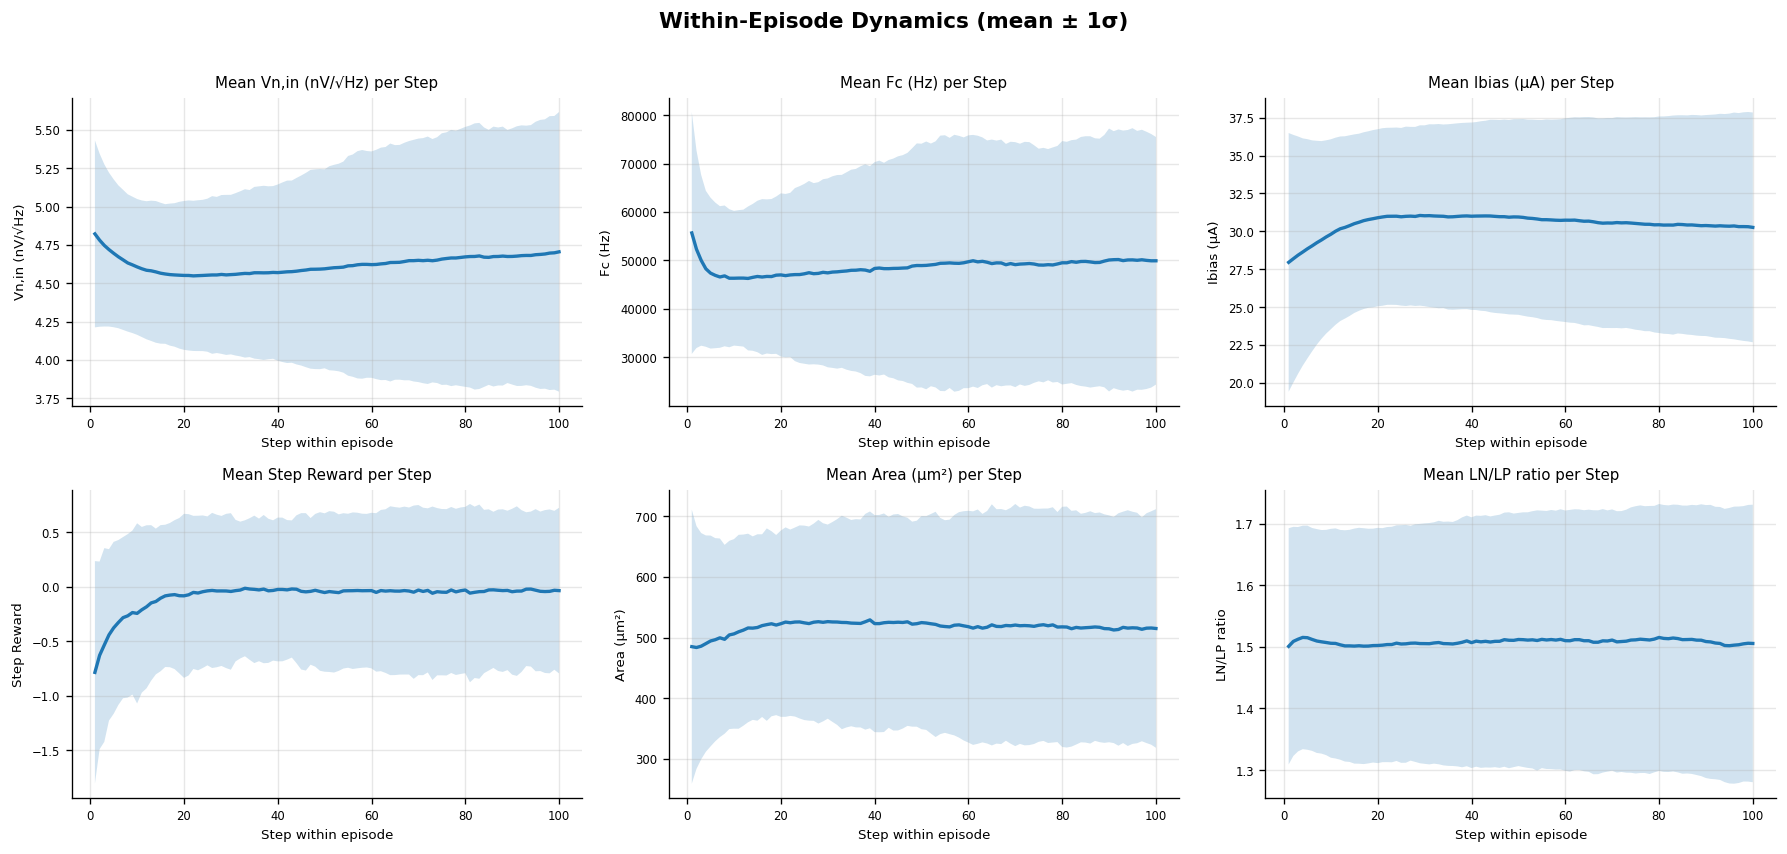

In [6]:
step_metrics = ['vn_in', 'fc', 'ibias_uA', 'reward', 'area_um2', 'ln_lp_ratio']
step_titles  = ['Vn,in (nV/√Hz)', 'Fc (Hz)', 'Ibias (µA)', 'Step Reward', 'Area (µm²)', 'LN/LP ratio']

# Average metric value by step index across ALL episodes
step_mean = step_df.groupby('step')[step_metrics].mean()
step_std  = step_df.groupby('step')[step_metrics].std()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, (m, title) in enumerate(zip(step_metrics, step_titles)):
    ax = axes[i]
    mu  = step_mean[m]
    sig = step_std[m]
    ax.plot(mu.index, mu.values, linewidth=2)
    ax.fill_between(mu.index, mu - sig, mu + sig, alpha=0.2)
    ax.set_xlabel('Step within episode', fontsize=8)
    ax.set_ylabel(title, fontsize=8)
    ax.set_title(f'Mean {title} per Step', fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle('Within-Episode Dynamics (mean ± 1σ)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5 · Distribution of Final Episode Metrics

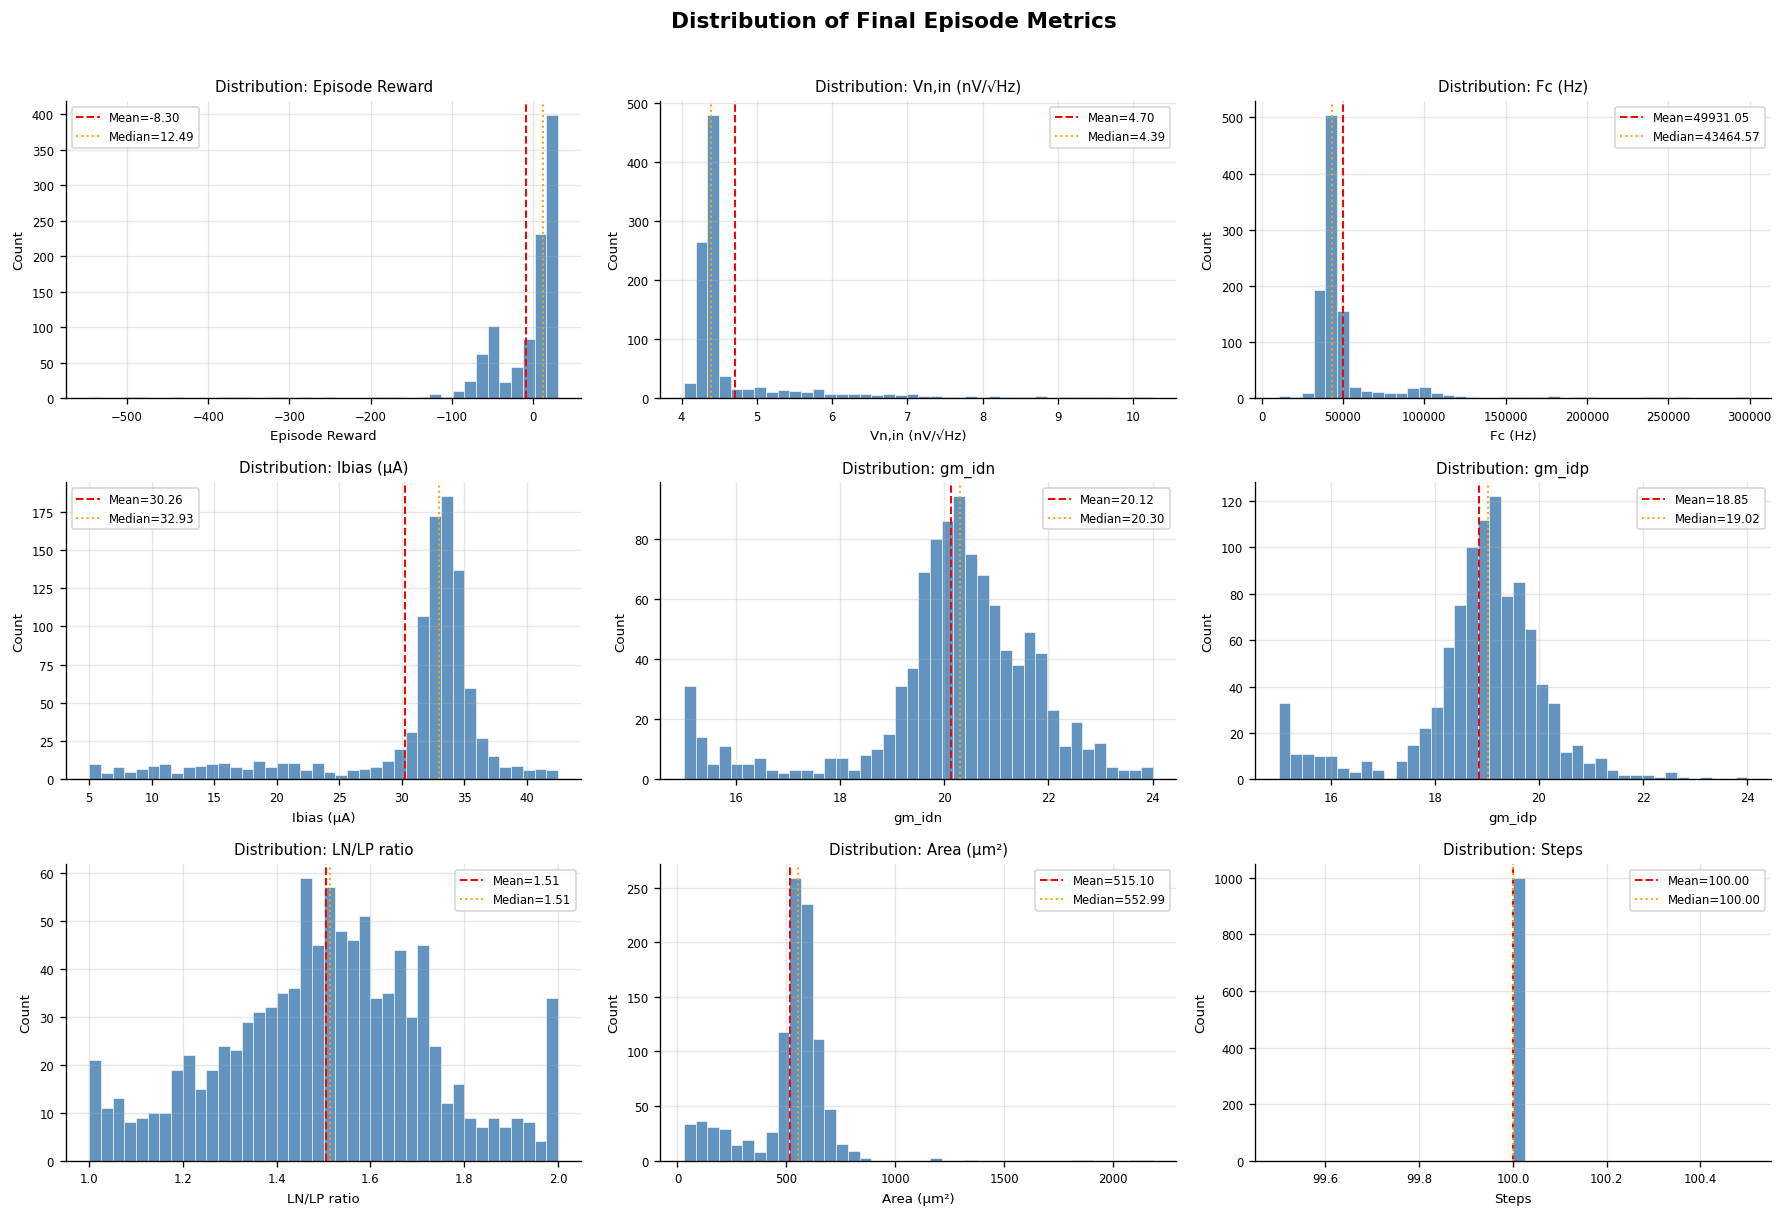

In [7]:
dist_params = ['reward', 'vn_in', 'fc', 'ibias_uA', 'gm_idn', 'gm_idp', 'ln_lp_ratio', 'area_um2', 'steps']
dist_titles = ['Episode Reward', 'Vn,in (nV/√Hz)', 'Fc (Hz)', 'Ibias (µA)', 'gm_idn', 'gm_idp', 'LN/LP ratio', 'Area (µm²)', 'Steps']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (p, title) in enumerate(zip(dist_params, dist_titles)):
    ax = axes[i]
    data = ep_df[p].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  linewidth=1.2, label=f'Median={data.median():.2f}')
    ax.set_xlabel(title, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.set_title(f'Distribution: {title}', fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Distribution of Final Episode Metrics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6 · Correlation Heatmap (Final Episode Values)

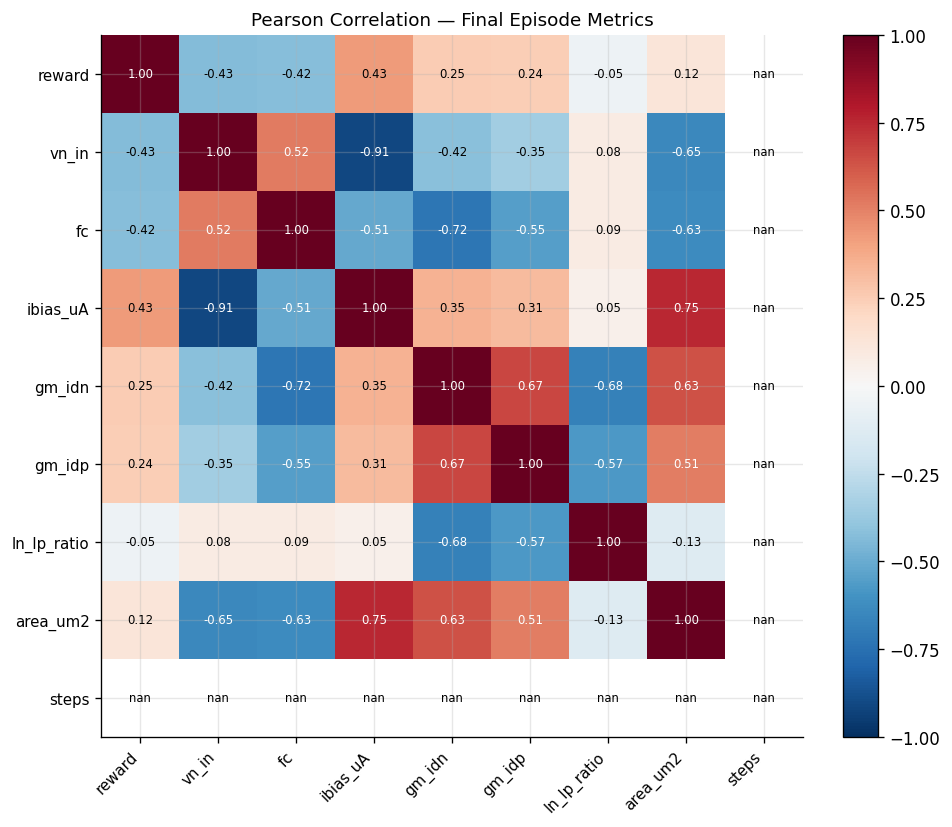

In [8]:
corr_cols = ['reward', 'vn_in', 'fc', 'ibias_uA', 'gm_idn', 'gm_idp', 'ln_lp_ratio', 'area_um2', 'steps']
corr = ep_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Pearson Correlation — Final Episode Metrics', fontsize=11)
plt.tight_layout()
plt.show()

## 7 · Early vs. Late Training Comparison

In [ ]:
n_eps    = len(ep_df)
split    = n_eps // 2
early_df = ep_df.iloc[:split]
late_df  = ep_df.iloc[split:]

compare_params = ['reward', 'vn_in', 'fc', 'ibias_uA', 'area_um2']
compare_titles = ['Reward', 'Vn,in (nV/√Hz)', 'Fc (Hz)', 'Ibias (µA)', 'Area (µm²)']

fig, axes = plt.subplots(1, len(compare_params), figsize=(16, 4))

for ax, p, title in zip(axes, compare_params, compare_titles):
    e_vals = early_df[p].dropna()
    l_vals = late_df[p].dropna()
    ax.boxplot([e_vals, l_vals], labels=['Early\n(ep 1–250)', 'Late\n(ep 251–500)'],
               patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle('Early vs. Late Training (box plots)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 · Design Constraint Satisfaction Over Training

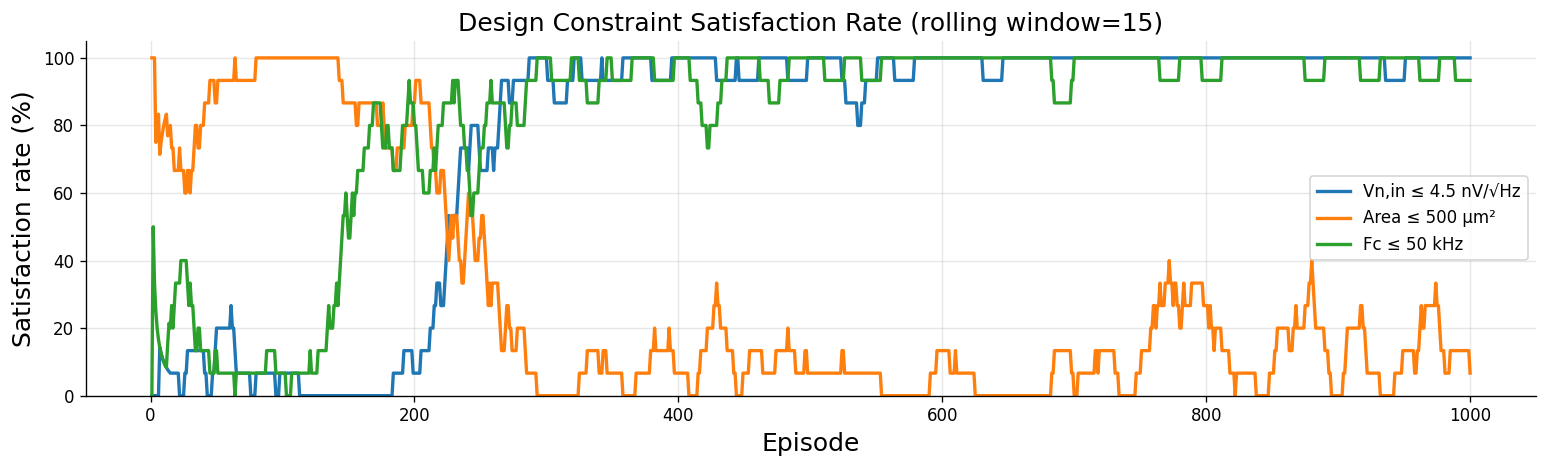

In [19]:
vnin_target    = cfg['vnin_target']        # 4.5 nV/√Hz
area_budget    = cfg['area_budget_um2']    # 500 µm²
ibias_lo, ibias_hi = cfg['IBIAS_RANGE']   # µA range stored as A
ep_df['vnin_ok']  = ep_df['vn_in']      <= vnin_target
ep_df['area_ok']  = ep_df['area_um2']   <= area_budget
# fc_ok already exists from episode log — no need to recompute
window2 = 15
fig, ax = plt.subplots(figsize=(13, 4))

for col, label, color in [
    ('vnin_ok', f'Vn,in ≤ {vnin_target} nV/√Hz', 'crimson'),
    ('area_ok', f'Area ≤ {area_budget} µm²', 'steelblue'),
    ('fc_ok',   f'Fc ≤ {50} kHz ', 'forestgreen'),
]:
    rate = ep_df[col].astype(float).rolling(window2, min_periods=1).mean() * 100
    ax.plot(ep_df['episode'], rate, label=label, linewidth=2)

ax.set_ylim(0, 105)
ax.set_xlabel('Episode', fontsize=15)
ax.set_ylabel('Satisfaction rate (%)', fontsize=15)
ax.set_title(f'Design Constraint Satisfaction Rate (rolling window={window2})', fontsize=15)
ax.legend(fontsize=10)
plt.savefig('Constraint_Satisfaction.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

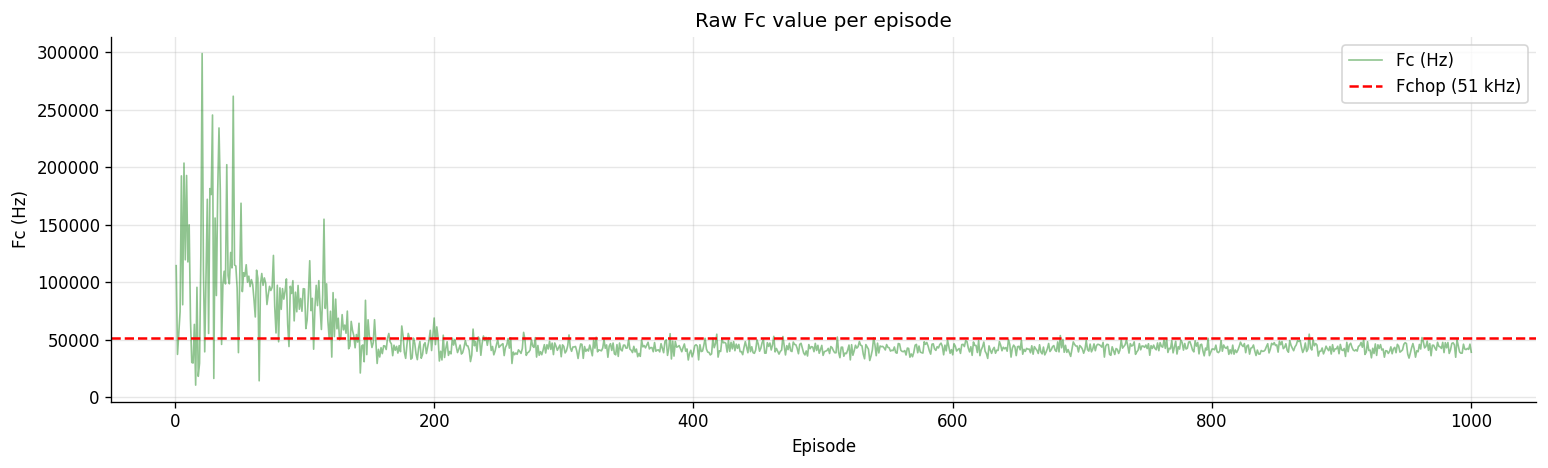

In [58]:
fig, ax2 = plt.subplots(figsize=(13, 4))
ax2.plot(ep_df['episode'], ep_df['fc'], label='Fc (Hz)', color='forestgreen', linewidth=1, alpha=0.5)
ax2.axhline(y=51000, color='red', linestyle='--', label='Fchop (51 kHz)')
ax2.set_xlabel('Episode')
ax2.set_ylabel('Fc (Hz)')
ax2.set_title('Raw Fc value per episode')
ax2.legend()
plt.tight_layout()
plt.show()

## 9 · Summary Table

In [59]:
summary = ep_df[['reward','vn_in','fc','ibias_uA','gm_idn','gm_idp','ln_lp_ratio','area_um2','steps']].describe().T
summary.columns = summary.columns.str.capitalize()
summary = summary[['Count','Mean','Std','Min','25%','50%','75%','Max']]
summary.index.name = 'Metric'
summary

,Count,Mean,Std,Min,25%,50%,75%,Max
Metric,,,,,,,,
reward,1000.0,-8.301072,54.234930,-546.6053,-23.656775,12.48580,20.382500,30.6795
vn_in,1000.0,4.704597,0.911878,4.0297,4.326900,4.38790,4.472950,10.2605
fc,1000.0,49931.049090,25565.021344,10442.1600,39829.567500,43464.56500,47461.565000,298661.8800
ibias_uA,1000.0,30.260212,7.577816,5.0000,30.904500,32.93050,34.258500,42.4810
gm_idn,1000.0,20.122334,1.743621,15.0000,19.657325,20.30420,21.154100,24.0000
gm_idp,1000.0,18.846530,1.328395,15.0000,18.442750,19.01815,19.569500,24.0000
ln_lp_ratio,1000.0,1.505526,0.225212,1.0000,1.366500,1.51345,1.653075,2.0000
area_um2,1000.0,515.095050,196.984794,29.1400,491.810000,552.98500,605.457500,2182.2100
steps,1000.0,100.000000,0.000000,100.0000,100.000000,100.00000,100.000000,100.0000
